In [18]:
# for working part
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# reading the parquet file created in notebook 2

lead_conversion_data = pd.read_parquet("C:\\Users\\hp5cd\\OneDrive\\Desktop\\Python\\lead-conversion-prediction\\data\\raw_data.parquet")

In [5]:
# removing null rows of assigned date as it is not needed

lead_conversion_data  =  lead_conversion_data[~lead_conversion_data['assigned_date'].isnull()]

In [6]:
lead_conversion_data.columns

Index(['lead_id_x', 'pii_id', 'owner', 'lead_source', 'assigned_date',
       'follow_up_date', 'contact_id', 'lead_id_y', 'profile', 'country',
       'state', 'total_duration', 'call_count', 'last_call_date',
       'first_call_date', 'distinct_call_days', 'connected_call_count',
       'missed_call_count', 'inbound_call_count', 'outbound_call_count',
       'converted'],
      dtype='object')

In [7]:
# extracting month and year from raw assigned date 

lead_conversion_data['assigned_month'] = lead_conversion_data['assigned_date'].dt.month
lead_conversion_data['assigned_year'] = lead_conversion_data['assigned_date'].dt.year

In [8]:
# followup done column
lead_conversion_data['followup_done'] = np.where(
    (lead_conversion_data['follow_up_date'].notna()) & (lead_conversion_data['last_call_date'] > lead_conversion_data['follow_up_date']),
     1,0 )

In [9]:
# adding new features from old columns


lead_conversion_data['average_duration'] = lead_conversion_data['total_duration']/lead_conversion_data['call_count']
lead_conversion_data['connection_rate'] = lead_conversion_data['connected_call_count'] / lead_conversion_data['call_count']
lead_conversion_data['miss_rate'] = lead_conversion_data['missed_call_count'] / lead_conversion_data['call_count']
lead_conversion_data['average_call_per_day'] = lead_conversion_data['call_count'] / lead_conversion_data['distinct_call_days']
lead_conversion_data['average_duration_per_day'] = lead_conversion_data['total_duration'] / lead_conversion_data['distinct_call_days']
lead_conversion_data['inbound_outbound_ratio'] = lead_conversion_data['inbound_call_count'] / lead_conversion_data['outbound_call_count']
lead_conversion_data['time_taken_for_first_touch'] = (lead_conversion_data['first_call_date'] - lead_conversion_data['assigned_date']).dt.days
lead_conversion_data['call_span_days'] = (lead_conversion_data['last_call_date'] - lead_conversion_data['first_call_date']).dt.days
lead_conversion_data['call_frequency'] = (lead_conversion_data['call_count'] / (lead_conversion_data["call_span_days"] + 1 ))

In [10]:
# removing not important columns for the model
lead_conversion_data = lead_conversion_data[
    [ 'owner', 'lead_source','profile', 'total_duration', 'call_count', 'distinct_call_days', 'connected_call_count',
       'missed_call_count', 'inbound_call_count', 'outbound_call_count', 'converted', 'assigned_month', 'assigned_year',
       'followup_done', 'average_duration', 'connection_rate', 'miss_rate', 'average_call_per_day', 'average_duration_per_day',
       'inbound_outbound_ratio', 'time_taken_for_first_touch', 'call_span_days', 'call_frequency']]

In [ ]:
# will do small EDA again on processed data

In [12]:
lead_conversion_data.isna().sum()

owner                              0
lead_source                        0
profile                       186011
total_duration                116956
call_count                    116956
distinct_call_days            116956
connected_call_count          116956
missed_call_count             116956
inbound_call_count            116956
outbound_call_count           116956
converted                          0
assigned_month                     0
assigned_year                      0
followup_done                      0
average_duration              116956
connection_rate               116956
miss_rate                     116956
average_call_per_day          116956
average_duration_per_day      116956
inbound_outbound_ratio        116956
time_taken_for_first_touch    116956
call_span_days                116956
call_frequency                116956
dtype: int64

In [17]:
lead_conversion_data['converted'].value_counts()

converted
0    472579
1    227421
Name: count, dtype: int64

lead count minimum 3672
lead count maximum 8160
conversion rate minimum 0.25765851341724055
conversion rate maximum 0.41014909756735546


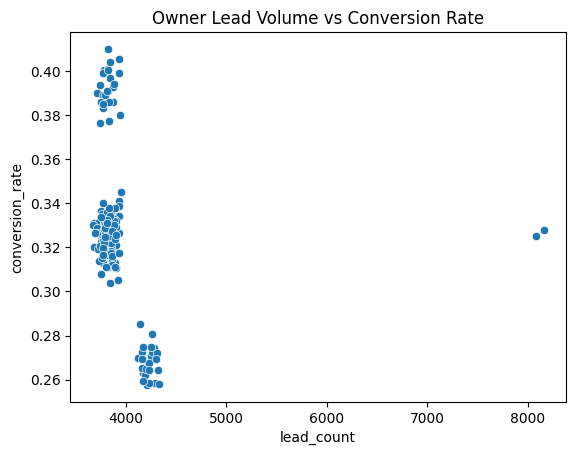

In [20]:
# checking importance of owner column in the datset, as it is a high cardinality column (unique values are high)

owner_stats = lead_conversion_data.groupby("owner").agg(lead_count = ('assigned_month','count'), conversion_rate = ('converted','mean'))

print("lead count minimum", owner_stats['lead_count'].min())
print("lead count maximum", owner_stats['lead_count'].max())
print("conversion rate minimum", owner_stats['conversion_rate'].min())
print("conversion rate maximum", owner_stats['conversion_rate'].max())


# creating a distribution graph for more clarification on owner impact 
sns.scatterplot(
    data=owner_stats,
    x='lead_count',
    y='conversion_rate'
)

plt.title("Owner Lead Volume vs Conversion Rate")
plt.show()




In [22]:
# finally loading the processed dataset into parquet file


lead_conversion_data.to_parquet("C:\\Users\\hp5cd\\OneDrive\\Desktop\\Python\\lead-conversion-prediction\\data\\processed_data.parquet",engine="fastparquet",index=False)